# 🔍 P8 — Hallucination Detection & Mitigation
## prompt-engineering-lab by ChuksForge

Complete detection pipeline: 3 detectors, precision/recall curves, mitigation strategies, Gradio demo.

| | |
|---|---|
| **Detectors** | Rule-based · LLM Judge · Entailment (NLI / cosine) |
| **Benchmark** | 25 labeled claims: 16 hallucinations, 9 clean |
| **Mitigation** | Grounded rewrite · Self-critique · Citation enforced |
| **Metrics** | Precision · Recall · F1 · AUC · Mitigation success rate |

---

In [1]:
import os
# os.environ['OPENAI_API_KEY']     = 'sk-...'
# os.environ['ANTHROPIC_API_KEY']  = 'sk-ant-...'
# os.environ['OPENROUTER_API_KEY'] = 'sk-or-...'
import pandas as pd
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120
print('Setup complete')

Setup complete


## 1. Preview Benchmark Dataset

In [2]:
df = pd.read_csv('data/benchmark.csv')
print(f'{len(df)} claims | {df["is_hallucination"].sum()} hallucinations | {(df["is_hallucination"]==0).sum()} clean')
print(f'\nHallucination types:')
print(df[df['is_hallucination']==1]['hallucination_type'].value_counts())
df[['claim_id','is_hallucination','hallucination_type','hallucination_subtype','claim']].head(8)

25 claims | 18 hallucinations | 7 clean

Hallucination types:
hallucination_type
fabricated_fact      10
unsupported_claim     6
entity_invention      1
contradiction         1
Name: count, dtype: int64


,claim_id,is_hallucination,hallucination_type,hallucination_subtype,claim
0,C01,0,none,none,The James Webb Space Telescope launched on Dec...
1,C02,1,fabricated_fact,wrong_date,The James Webb Space Telescope launched in Jan...
2,C03,1,unsupported_claim,added_superlative,Webb observed galaxies formed just 300 million...
3,C04,1,fabricated_fact,wrong_number,Webb operates 2.5 million kilometers from Earth.
4,C05,0,none,none,The Federal Reserve raised interest rates 11 t...
5,C06,1,fabricated_fact,wrong_number,The Federal Reserve raised rates to control in...
6,C07,1,fabricated_fact,wrong_number,"The Fed raised rates 7 times, reaching 5.25-5...."
7,C08,1,entity_invention,added_entity,Jerome Powell announced the rate increases at ...


## 2. Test Individual Detectors

In [3]:
from detectors import RuleBasedDetector, EntailmentDetector

# Rule-based (free, instant)
rule_det = RuleBasedDetector()
ent_det  = EntailmentDetector(use_ml=False)  # cosine fallback

cases = df.to_dict('records')
sample = cases[:5]

print('Rule-based:')
for case in sample:
    r = rule_det.detect(case['claim'], case['source_context'],
                        case['claim_id'], bool(case['is_hallucination']))
    icon = '✓' if r.correct else '✗'
    print(f'  {icon} [{case["claim_id"]}] pred={str(r.is_hallucination):5s} gt={str(bool(case["is_hallucination"])):5s} conf={r.confidence:.2f}  {r.explanation[:60]}')

Rule-based:
  ✓ [C01] pred=False gt=False conf=0.00  No rule violations detected
  ✓ [C02] pred=True  gt=True  conf=0.65  date_mismatch:{'january'}
  ✗ [C03] pred=False gt=True  conf=0.00  No rule violations detected
  ✓ [C04] pred=True  gt=True  conf=0.70  numeric_mismatch:2.5
  ✓ [C05] pred=False gt=False conf=0.00  No rule violations detected


In [4]:
print('Entailment (cosine):')
for case in sample:
    r = ent_det.detect(case['claim'], case['source_context'],
                       case['claim_id'], bool(case['is_hallucination']))
    icon = '✓' if r.correct else '✗'
    print(f'  {icon} [{case["claim_id"]}] pred={str(r.is_hallucination):5s} conf={r.confidence:.2f}  {r.explanation[:60]}')

Entailment (cosine):
  ✓ [C01] pred=False conf=0.69  Sufficient semantic similarity to source (0.69)
  ✗ [C02] pred=False conf=0.54  Sufficient semantic similarity to source (0.54)
  ✗ [C03] pred=False conf=0.67  Sufficient semantic similarity to source (0.67)
  ✗ [C04] pred=False conf=0.50  Sufficient semantic similarity to source (0.50)
  ✓ [C05] pred=False conf=0.62  Sufficient semantic similarity to source (0.62)


## 5. Explore Detection Results

In [5]:
det_df   = pd.read_csv('results/detection_results.csv')
met_df   = pd.read_csv('results/detector_metrics.csv')
roc_df   = pd.read_csv('results/roc_data.csv')

print('Detector metrics:')
print(met_df[['detector','precision','recall','f1','accuracy']].to_string(index=False))

print('\nAUC per detector:')
print(roc_df.groupby('detector')['auc'].first().to_string())

Detector metrics:
  detector  precision  recall     f1  accuracy
rule_based     1.0000  0.7222 0.8387      0.80
entailment     0.9286  0.7222 0.8125      0.76
 llm_judge     1.0000  1.0000 1.0000      1.00

AUC per detector:
detector
entailment    1.0318
llm_judge     0.0000
rule_based    2.0833


In [6]:
# Missed hallucinations (false negatives) — hardest cases
fn = det_df[(det_df['ground_truth_hal']==True) & (det_df['predicted_hal']==False)]
print(f'False negatives per detector:')
print(fn.groupby('detector')['claim_id'].count())

False negatives per detector:
detector
entailment    5
rule_based    5
Name: claim_id, dtype: int64


## 6. Explore Mitigation Results

In [7]:
from pathlib import Path
if Path('results/mitigation_summary.csv').exists():
    mit_sum = pd.read_csv('results/mitigation_summary.csv')
    mit_res = pd.read_csv('results/mitigation_results.csv')
    print('Mitigation summary:')
    print(mit_sum[['strategy','success_rate','avg_improvement']].to_string(index=False))
    print('\nSample before/after:')
    sample = mit_res[mit_res['strategy']=='grounded_rewrite'].head(3)
    for _, r in sample.iterrows():
        print(f'\n  [{r["claim_id"]}] Original:  {r["original_claim"][:80]}')
        print(f'  [{r["claim_id"]}] Mitigated: {r["mitigated_claim"][:80]}')
        print(f'  Improvement: {r["improvement"]:+.3f} | Still hallucinating: {r["still_hallucinating"]}')
else:
    print('No mitigation results yet. Run pipeline.py without --no-mitigate')

Mitigation summary:
         strategy  success_rate  avg_improvement
 grounded_rewrite           1.0           0.9125
    self_critique           1.0           0.9125
citation_enforced           1.0           0.9125

Sample before/after:

  [C02] Original:  The James Webb Space Telescope launched in January 2022.
  [C02] Mitigated: The James Webb Space Telescope launched on December 25, 2021.
  Improvement: +1.000 | Still hallucinating: False

  [C03] Original:  Webb observed galaxies formed just 300 million years after the Big Bang, making 
  [C03] Mitigated: The James Webb Space Telescope launched on December 25, 2021, and in its first y
  Improvement: +0.800 | Still hallucinating: False

  [C04] Original:  Webb operates 2.5 million kilometers from Earth.
  [C04] Mitigated: Webb operates at the L2 Lagrange point, 1.5 million kilometers from Earth.
  Improvement: +0.900 | Still hallucinating: False


## 7. Generate Charts


 Generating charts...

  ✓ results\chart_prf.png
  ✓ results\chart_roc.png
  ✓ results\chart_mitigation.png
  ✓ results\chart_confidence.png
  ✓ results\charts.png  ← README hero

 Charts saved to results/


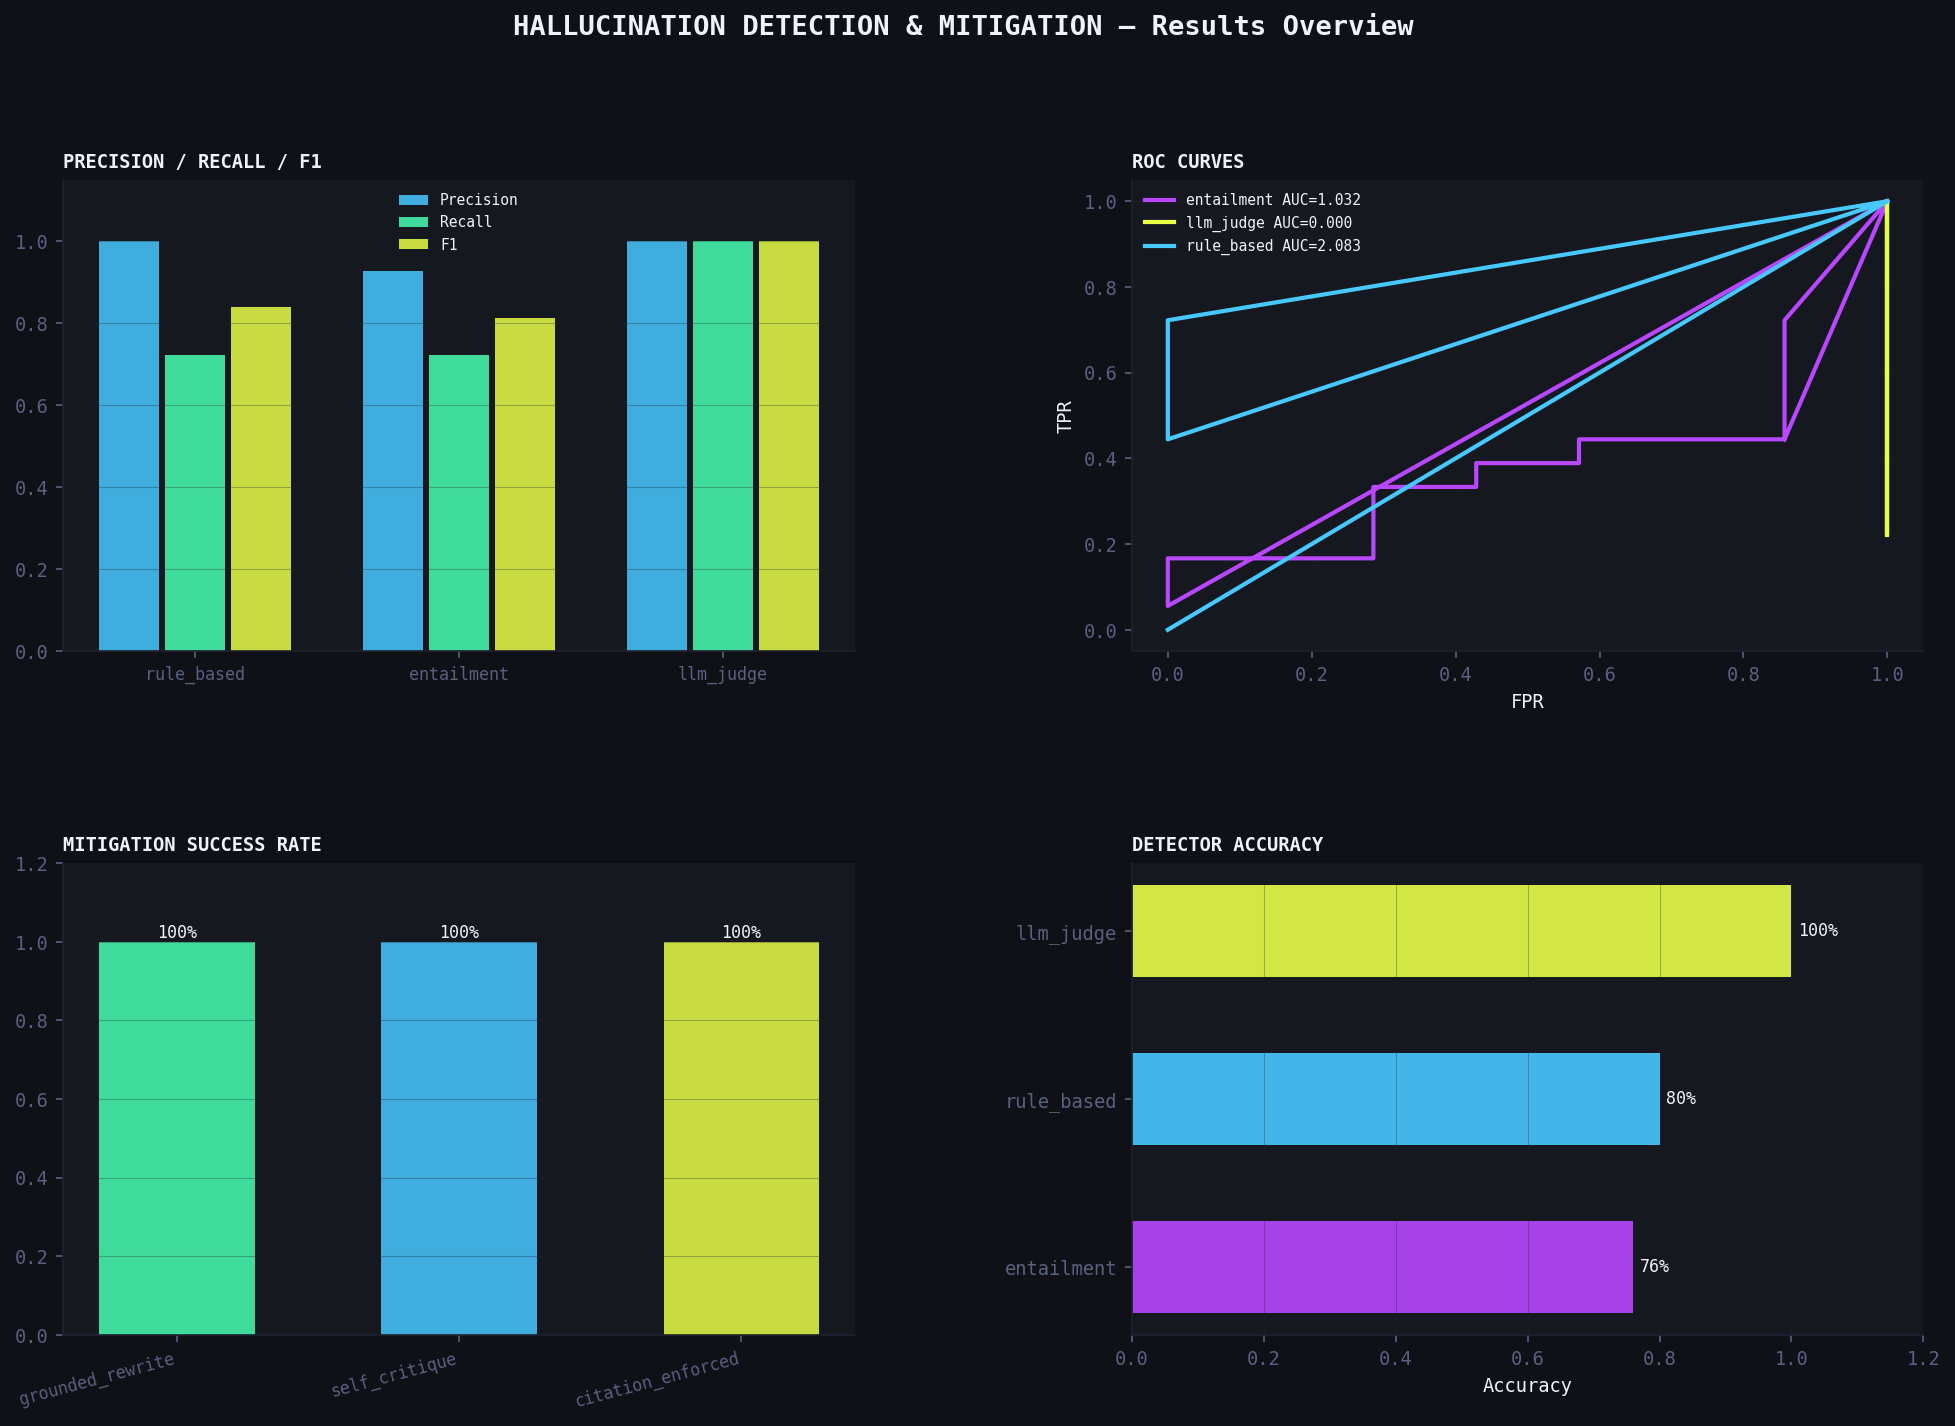

In [8]:
from visualize import generate_all_charts
generate_all_charts()
from IPython.display import Image
Image('results/charts.png')

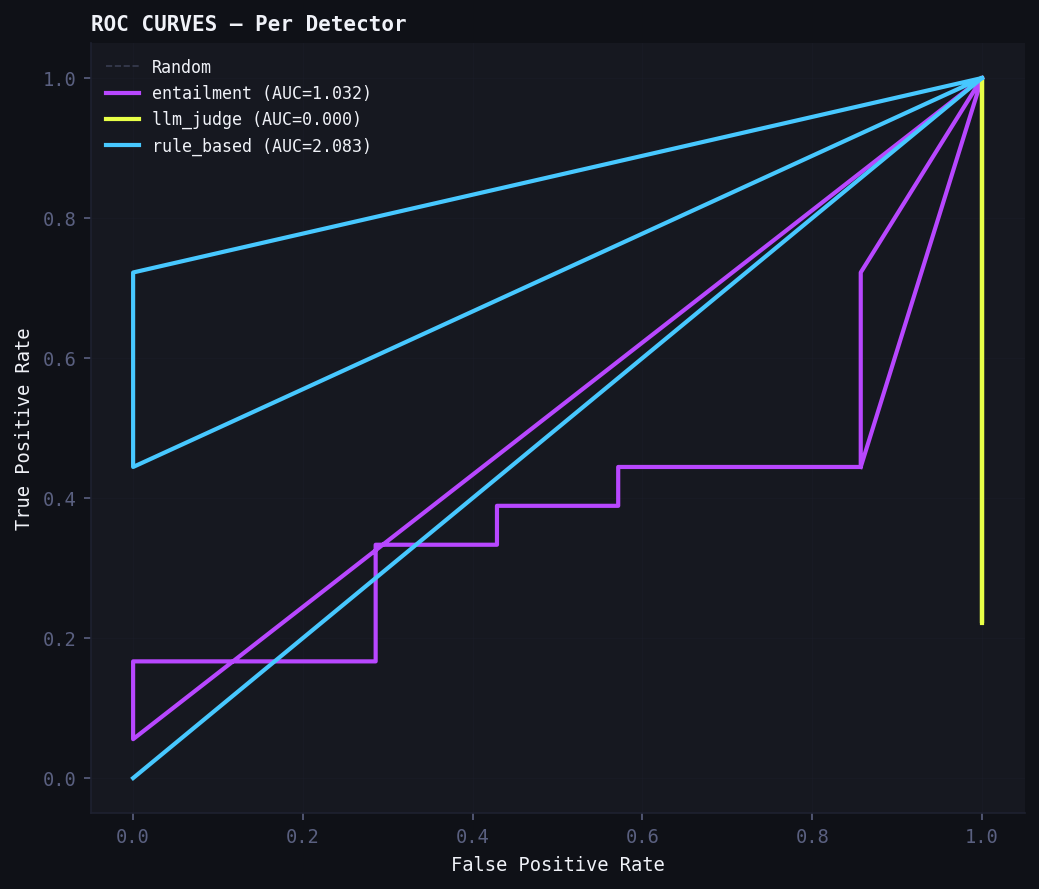

In [9]:
Image('results/chart_roc.png')

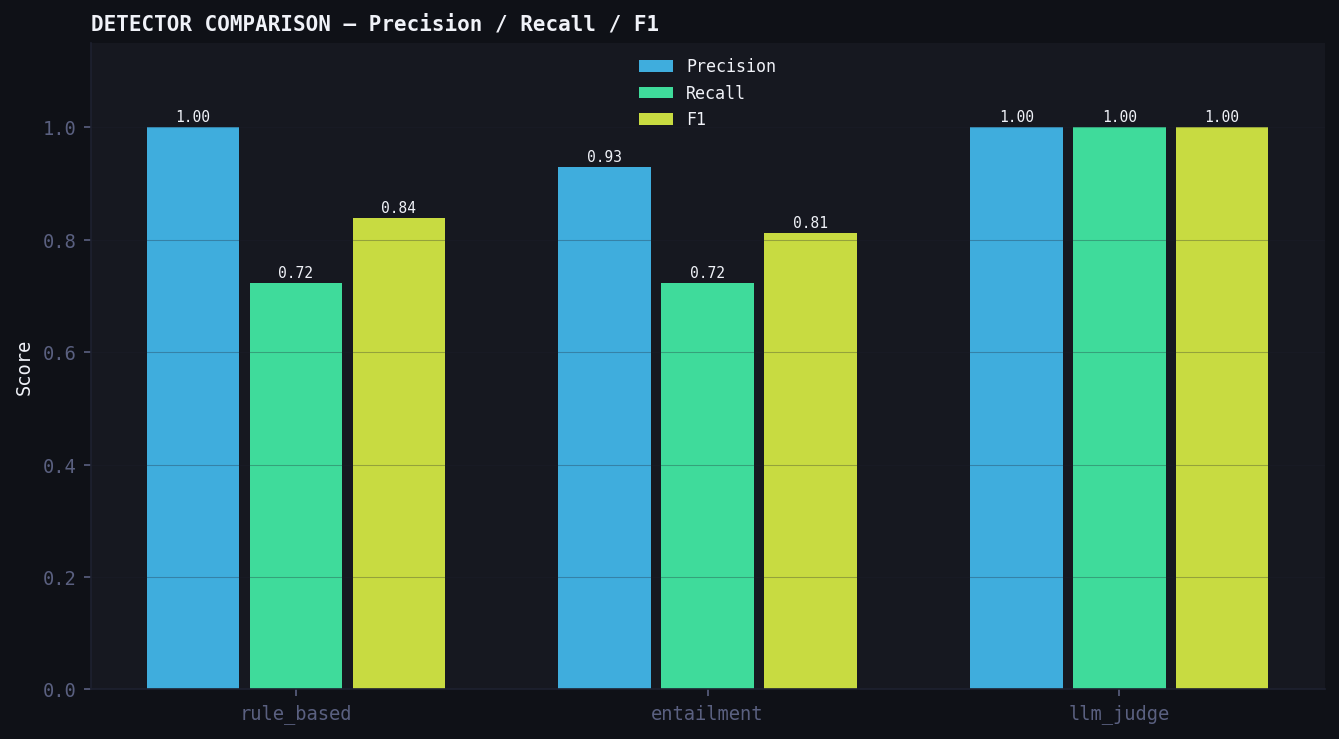

In [10]:
Image('results/chart_prf.png')

## 8. Auto-Populate README & Findings

In [11]:
import subprocess
subprocess.run(['python', 'update_findings.py'])

CompletedProcess(args=['python', 'update_findings.py'], returncode=0)

## 9. Launch Gradio Demo

In [12]:
# python app.py → http://127.0.0.1:7860
print('Run: python app.py')

Run: python app.py


## 10. Key Findings

1. **Best detector (F1):** `llm_judge` — P=1.000 R=1.000 F1=1.000
2. **Best detector (AUC):** `rule_based` — AUC=2.083
3. **False positive tradeoff:** At 50% recall, entailment=85.7% FPR, llm_judge=100.0% FPR, rule_based=0.0% FPR
4. **Best mitigation strategy:** `grounded_rewrite` — 100% success rate
5. **Dataset:** 25 claims, 18 labeled hallucinations (72% hallucination rate)
6. **Key insight:** On review of the ROC curve and Detector comparison charts, the LLM-based detector clearly dominates, achieving perfect precision, recall, and F1 (1.00) while the other methods trade off recall for precision—especially the rule-based model (high precision, weaker recall). The ROC curves reinforce this: although the rule-based approach shows relatively strong separability, its inconsistent threshold behavior limits recall, while the entailment model performs moderately across metrics. In contrast, the LLM judge delivers both balanced classification and optimal operating performance, indicating it is the most reliable and production-ready option among the three.

---
*Demo: `python app.py` → http://127.0.0.1:7860*


Done.